#SERS - CP01: Análise de Dados

**Objetivo:**
Aplicar os procedimentos trabalhados em aula para preparar, inspecionar e analisar diferentes conjuntos de dados do setor de energia, relacionando cada operação realizada ao contexto do dataset.

**Entrega:**
Todos os exercícios de Python devem ser resolvidos em um único arquivo Notebook Python (.ipynb). Organize o notebook com títulos em Markdown para identificar o dataset e cada exercício. Mantenha os códigos executados, os resultados visíveis e as respostas interpretativas no próprio notebook.

**Integrantes:**
- RM: 568992, Caio Henrique Ferraz da Silva
- RM: 570908, Enzo Caruso Peter
- RM: 573653, Leonardo Figueredo dos Santos
- RM: 570329, Leonardo Robert Maulicino
- RM: 573901, Lucas Ramos de Sousa
- RM: 569894, Pablo Renato dos Santos Sobral de Carvalho

In [201]:
import pandas as pd
import matplotlib.pyplot as plt

##Dataset 1: Appliances Energy Prediction - UCI

**Fonte:** https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

**Situação:**
Uma empresa de eficiência energética está analisando o comportamento de uma residência de baixo consumo. A equipe deseja identificar períodos de consumo elevado dos eletrodomésticos e observar quais condições de temperatura e umidade estavam presentes nesses momentos.

**Colunas:**
Appliances, lights, pelo menos três atributos de temperatura e três de umidade

**Tamanho da Amostra:**
10% dos registros

####Fluxo do Orange:
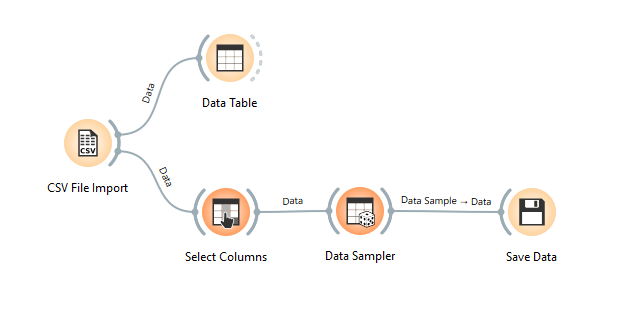

####Etapas:
1. Carregue a amostra no Pandas e apresente head(), shape, info() e describe().

2. Renomeie Appliances para Consumo_Eletrodomesticos e simplifique o nome de pelo menos três atributos ambientais.

3. Determine o maior consumo de eletrodomésticos registrado na amostra.

4. Calcule um limiar correspondente a 70% do valor máximo e crie um DataFrame contendo somente os registros acima desse limite.

5. Conte os registros selecionados e calcule qual percentual da amostra eles representam.

6. Calcule a temperatura média de T1 e crie outro DataFrame contendo simultaneamente consumo acima de 70% do máximo e temperatura acima da média.

7. Compare os dois DataFrames e explique o efeito da inclusão da temperatura como segundo critério.

In [202]:
#Carregar Amostras
ds1 = pd.read_csv('/content/appliances_energy_prediction_sample.csv')

In [203]:
#Mostrar head
ds1.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


In [204]:
#Mostrar shape (linhas e colunas)
print(f'Qnt. linhas: {ds1.shape[0]}')
print(f'Qnt. colunas: {ds1.shape[1]}')

Qnt. linhas: 1974
Qnt. colunas: 8


In [205]:
#Mostrar informações
ds1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Appliances  1974 non-null   int64  
 1   lights      1974 non-null   int64  
 2   T1          1974 non-null   float64
 3   RH_1        1974 non-null   float64
 4   T2          1974 non-null   float64
 5   RH_2        1974 non-null   float64
 6   T3          1974 non-null   float64
 7   RH_3        1974 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 123.5 KB


In [206]:
#Mostrar descrição
ds1.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,93.044580,3.839919,21.664703,40.219193,20.293635,40.411386,22.231615,39.209733
std,93.826149,7.937076,1.574883,3.971923,2.126958,4.037686,1.957275,3.288818
min,20.000000,0.000000,16.790000,27.733300,16.100000,24.063300,17.200000,30.133300
25%,50.000000,0.000000,20.700000,37.205825,18.790000,37.760000,20.700000,36.900000
50%,60.000000,0.000000,21.600000,39.590000,20.000000,40.433300,22.100000,38.433300
75%,100.000000,0.000000,22.600000,42.991675,21.500000,43.228325,23.290000,41.741250
max,770.000000,50.000000,26.260000,57.496700,28.917500,56.026700,29.198600,49.226700


In [207]:
ds1.columns

Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3'], dtype='object')

In [208]:
#Renomeie Appliances para Consumo_Eletrodomesticos e simplifique o nome de pelo menos três atributos ambientais.
ds1 = ds1.rename(columns={
    'Appliances': 'Consumo_Eletrodomesticos',
    'T1': 'Temperatura_1',
    'RH_1': 'Umidade_1',
    'T2': 'Temperatura_2',
    'RH_2': 'Umidade_2',
    'T3': 'Temperatura_3',
    'RH_3': 'Umidade_3'
})

ds1.head()

,Consumo_Eletrodomesticos,lights,Temperatura_1,Umidade_1,Temperatura_2,Umidade_2,Temperatura_3,Umidade_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


In [209]:
#Determine o maior consumo de eletrodomésticos registrado na amostra.
maior_consumo = ds1['Consumo_Eletrodomesticos'].max()

print(f"O maior consumo de eletrodomésticos registrado é {maior_consumo:.2f}")

O maior consumo de eletrodomésticos registrado é 770.00


In [210]:
#Calcule um limiar correspondente a 70% do valor máximo e crie um DataFrame contendo somente os registros acima desse limite.
limiar = 0.7 * maior_consumo

print(f'O limiar de 70% do consumo máximo é {limiar:.2f}')
print()

df1 = ds1[ds1['Consumo_Eletrodomesticos'] > limiar]

df1.head()

O limiar de 70% do consumo máximo é 539.00



,Consumo_Eletrodomesticos,lights,Temperatura_1,Umidade_1,Temperatura_2,Umidade_2,Temperatura_3,Umidade_3
352,620,0,24.3900,44.3333,25.3700,37.7360,26.7300,38.8633
427,650,0,20.8900,36.7000,18.2900,39.6633,21.2000,36.0000
453,560,30,21.3567,36.0900,19.5667,37.1633,21.6333,35.0300
616,570,10,24.8900,32.6667,23.5600,31.1400,23.6000,30.8233
696,590,30,19.8567,47.6633,18.7000,34.1000,18.4267,37.8333


In [211]:
#Conte os registros selecionados e calcule qual percentual da amostra eles representam.
selecionados = df1.shape[0]
total = ds1.shape[0]
percentual = selecionados / total * 100

print(f"Os {selecionados} registros selecionados representa {percentual:.2f}% da amostra.")

Os 22 registros selecionados representa 1.11% da amostra.


In [212]:
#Calcule a temperatura média de T1 e crie outro DataFrame contendo simultaneamente consumo acima de 70% do máximo e temperatura acima da média
media_temp = ds1['Temperatura_1'].mean()

print(f'A temperatura média de T1 é {media_temp:.2f}')
print()

df2 = df1[df1['Temperatura_1'] > media_temp]

df2.head()

A temperatura média de T1 é 21.66



,Consumo_Eletrodomesticos,lights,Temperatura_1,Umidade_1,Temperatura_2,Umidade_2,Temperatura_3,Umidade_3
352,620,0,24.3900,44.3333,25.3700,37.7360,26.73,38.8633
616,570,10,24.8900,32.6667,23.5600,31.1400,23.60,30.8233
916,750,30,22.4300,43.0000,21.9267,40.1333,21.23,42.5967
993,690,10,22.5333,45.0267,22.0667,39.7900,22.39,41.9300
1182,600,20,24.8900,48.1333,28.9175,37.9475,27.10,42.4400


In [213]:
tamanho_temp = df2.shape[0]

print(f"O dataframe 2 tem {tamanho_temp} registros, {selecionados - tamanho_temp} a menos que o dataframe 1.")

O dataframe 2 tem 8 registros, 14 a menos que o dataframe 1.


In [214]:
#Compare os dois DataFrames e explique o efeito da inclusão da temperatura como segundo critério.
'''
Ao adicionar um critério a um dataframe, como apenas os que estão acima
de 70% do consumo máximo, limita-se a quantidade de registros apenas àquele
critério, excluindo os que não cabem nele.

Ao adicionar um segundo critério, sua exclusão se soma ao primeiro, pois
independentemente da ordem em que são adicionados, ambos os critérios
precisam ser atendidos para que um registro seja selecionado, assim
diminuindo consideravelmente o número de registros.
'''

'\nAo adicionar um critério a um dataframe, como apenas os que estão acima\nde 70% do consumo máximo, limita-se a quantidade de registros apenas àquele\ncritério, excluindo os que não cabem nele.\n\nAo adicionar um segundo critério, sua exclusão se soma ao primeiro, pois\nindependentemente da ordem em que são adicionados, ambos os critérios\nprecisam ser atendidos para que um registro seja selecionado, assim\ndiminuindo consideravelmente o número de registros.\n'

##Dataset 2: Steel Industry Energy Consumption  - UCI

**Fonte:** https://archive.ics.uci.edu/dataset/851/steel+industry+energy+consumption

**Situação:**
A equipe de gestão de energia de uma indústria siderúrgica deseja localizar situações de consumo elevado e verificar se esses períodos coincidem com condições de carga elevada ou valores menos favoráveis de fator de potência.

**Colunas:**
 Usage_kWh, as variáveis de potência reativa, os fatores de potência, WeekStatus, Day_of_week e Load_Type

**Tamanho da Amostra:**
20% dos registros

####Fluxo do Orange:
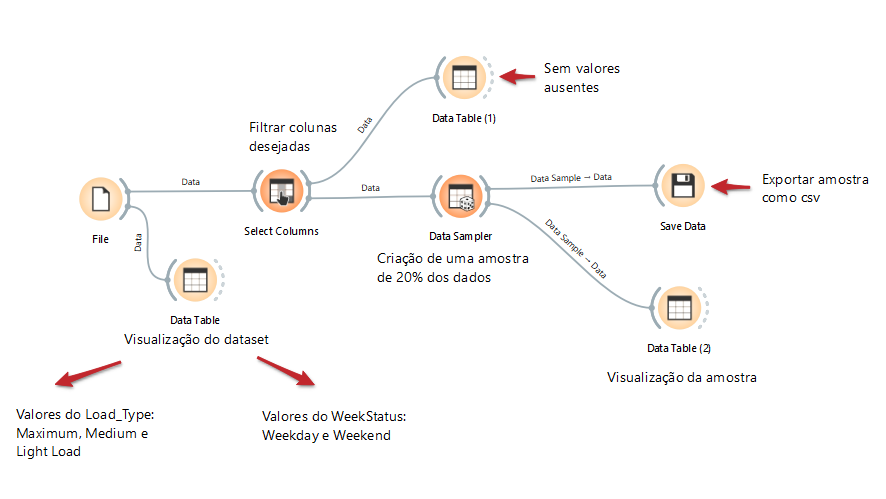

####Etapas:

1. Carregue a amostra e renomeie Usage_kWh para Consumo_kWh, simplificando também os nomes dos atributos de fator de potência.

2. Apresente uma inspeção inicial com head(), shape, info() e describe().

3. Determine o maior consumo registrado e calcule um limiar de 75% do consumo máximo.

4. Crie um DataFrame contendo os registros acima desse limiar e calcule a quantidade e o percentual de registros.

5. Verifique quantos registros desse DataFrame pertencem à categoria Maximum Load.

6. Escolha um dos atributos de fator de potência, observe seus valores e defina um limite coerente para representar valores mais baixos.

7. Crie um novo DataFrame contendo simultaneamente consumo elevado e fator de potência abaixo do limite escolhido.

8. Explique por que esse segundo conjunto de registros pode merecer maior atenção da equipe de energia.

In [215]:
# 1. Carregue a amostra e renomeie Usage_kWh para Consumo_kWh, simplificando também os nomes dos atributos de fator de potência.

df_steel_industry = pd.read_csv('/content/steel_industry_energy_consumption_sample.csv')
df_steel_industry.rename( columns = {'Usage_kWh': 'Consumo_kWh',
                          'Lagging_Current_Power_Factor': 'Fator_potencia_atrasado',
                          'Leading_Current_Power_Factor': 'Fator_potencia_adiantado'}, inplace = True)

In [216]:
# 2. Apresente uma inspeção inicial com head(), shape, info() e describe().

df_steel_industry.head()
df_steel_industry.columns

Index(['date', 'Consumo_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'Fator_potencia_atrasado',
       'Fator_potencia_adiantado', 'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')

In [217]:
df_steel_industry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  7008 non-null   object 
 1   Consumo_kWh                           7008 non-null   float64
 2   Lagging_Current_Reactive.Power_kVarh  7008 non-null   float64
 3   Leading_Current_Reactive_Power_kVarh  7008 non-null   float64
 4   Fator_potencia_atrasado               7008 non-null   float64
 5   Fator_potencia_adiantado              7008 non-null   float64
 6   WeekStatus                            7008 non-null   object 
 7   Day_of_week                           7008 non-null   object 
 8   Load_Type                             7008 non-null   object 
dtypes: float64(5), object(4)
memory usage: 492.9+ KB


In [218]:
df_steel_industry.describe()

,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Fator_potencia_atrasado,Fator_potencia_adiantado
count,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,27.790164,13.206839,3.803711,80.672277,84.491448
std,33.717719,16.444246,7.356412,18.869855,30.314798
min,2.450000,0.000000,0.000000,37.870000,12.710000
25%,3.200000,2.380000,0.000000,63.602500,99.710000
50%,4.570000,5.040000,0.000000,87.990000,100.000000
75%,52.107500,22.977500,1.857500,98.842500,100.000000
max,153.140000,87.700000,27.650000,100.000000,100.000000


In [219]:
n_linhas = df_steel_industry.shape[0]
n_colunas = df_steel_industry.shape[1]

print(f"O Dataframe possui {n_linhas} linhas x {n_colunas} colunas")

O Dataframe possui 7008 linhas x 9 colunas


In [220]:
# 3. Determine o maior consumo registrado e calcule um limiar de 75% do consumo máximo.

consumo_maximo = df_steel_industry['Consumo_kWh'].max()
print(f"O maior registrado foi {consumo_maximo} kWh")

Consumo75 = consumo_maximo*0.75
print(f"O limiar de 75% do consumo máximo é {Consumo75:.2f}")

O maior registrado foi 153.14 kWh
O limiar de 75% do consumo máximo é 114.85


In [221]:
# 4. Crie um DataFrame contendo os registros acima desse limiar e calcule a quantidade e o percentual de registros.

df_alto = df_steel_industry[df_steel_industry['Consumo_kWh'] >= Consumo75]

n_registros_altos = df_alto.shape[0]
percentual_registros = (n_registros_altos / df_steel_industry.shape[0])*100

print(f"O número de registros acima desse limiar é {n_registros_altos}, sendo {percentual_registros:.2f}% dos registros")

O número de registros acima desse limiar é 129, sendo 1.84% dos registros


In [222]:
# 5.	Verifique quantos registros desse DataFrame pertencem à categoria Maximum Load.

maximum_load = df_alto[df_alto['Load_Type'] == 'Maximum_Load']
print(f"{maximum_load.shape[0]} registros pertencem à categoria \"Maximum Load\"")

62 registros pertencem à categoria "Maximum Load"


In [223]:
# 6.	Escolha um dos atributos de fator de potência, observe seus valores e defina um limite coerente para representar valores mais baixos.
FP_adiantado = df_steel_industry['Fator_potencia_adiantado']
FP_adiantado.describe()

,Fator_potencia_adiantado
count,7008.000000
mean,84.491448
std,30.314798
min,12.710000
25%,99.710000
50%,100.000000
75%,100.000000
max,100.000000


<Axes: >

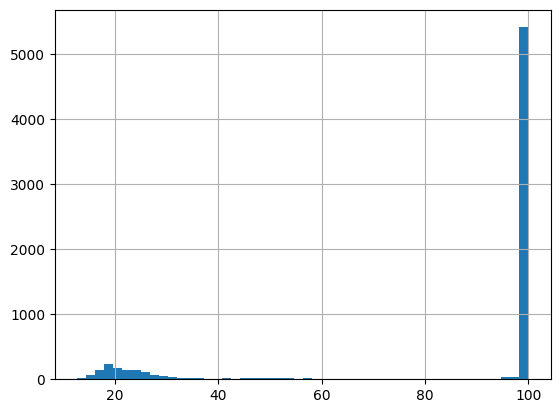

In [224]:
'''
Observando os dados descritivos, uma possibilidade seria definir valores baixos utilizando a média menos um desvio-padrão. Entretanto,
essa abordagem pressupõe uma distribuição aproximadamente simétrica,o que não parece ser adequado para este atributo. Por isso, foi
analisado o histograma para compreender melhor sua distribuição.
'''

FP_adiantado.hist(bins=50)

In [225]:
'''
Observando o histograma, confirma-se que há uma forte concentração dos valores de fator de potência adiantado nas faixas mais altas,
próximas de 90% a 100%, enquanto uma quantidade significativamente menor de registros apresenta valores inferiores. Dessa forma,
a distribuição apresenta uma concentração elevada à direita e uma cauda de valores mais baixos. Com base nela, escolhemos
adotar 60% como limite de valores baixos de fator de potência adiantado.
'''

FP_adiantado_baixo = 60

df_FP_adiantado_baixo = df_steel_industry[df_steel_industry['Fator_potencia_adiantado'] <= FP_adiantado_baixo]
df_FP_adiantado_baixo.sort_values('Fator_potencia_adiantado', inplace = True)
print(df_FP_adiantado_baixo['Fator_potencia_adiantado'])

4910    12.71
1668    12.79
6631    13.01
6381    13.05
6728    13.27
        ...  
248     59.25
5582    59.34
30      59.39
4143    59.57
3274    59.87
Name: Fator_potencia_adiantado, Length: 1429, dtype: float64


/tmp/ipykernel_4299/3615070856.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_FP_adiantado_baixo.sort_values('Fator_potencia_adiantado', inplace = True)


In [226]:
# 7. Crie um novo DataFrame contendo simultaneamente consumo elevado e fator de potência abaixo do limite escolhido.

df_consumoElevado_FPBaixo = df_steel_industry[(df_steel_industry['Consumo_kWh'] >= Consumo75)
& (df_steel_industry['Fator_potencia_adiantado'] <= FP_adiantado_baixo)]
print(df_consumoElevado_FPBaixo)

Empty DataFrame
Columns: [date, Consumo_kWh, Lagging_Current_Reactive.Power_kVarh, Leading_Current_Reactive_Power_kVarh, Fator_potencia_atrasado, Fator_potencia_adiantado, WeekStatus, Day_of_week, Load_Type]
Index: []


In [227]:
# 8. Explique por que esse segundo conjunto de registros pode merecer maior atenção da equipe de energia.

'''
O novo DataFrame pode ser usado pela equipe de energia como indicação de situações que merecem investigação, pois reúne registros de
situações de alto consumo de energia, mas que possuem um fator de potência abaixo ao estabelecido. Essa combinação
pode indicar uma utilização menos eficiente da energia elétrica, podendo resultar em maiores gastos operacionais para a indústria
siderúrgica. Com efeito, caso esse cenário seja comprovado, o equipamento poderá passar por manutenções ou ser
substituído, por exemplo.

Além disso, como o DataFrame contém a coluna referente ao dia da semana, pode-se analisar a ocorrência de situações de alto
consumo associadas a baixo fator de potência em diferentes dias. Essa análise pode revelar padrões relacionados aos dias em
que há maior frequência dessas ocorrências, direcionando investigações sobre possíveis mudanças na linha de produção ou nas
condições de operação em dias específicos da semana que possam estar associadas a um uso menos eficiente da energia elétrica.
'''

'\nO novo DataFrame pode ser usado pela equipe de energia como indicação de situações que merecem investigação, pois reúne registros de\nsituações de alto consumo de energia, mas que possuem um fator de potência abaixo ao estabelecido. Essa combinação\npode indicar uma utilização menos eficiente da energia elétrica, podendo resultar em maiores gastos operacionais para a indústria\nsiderúrgica. Com efeito, caso esse cenário seja comprovado, o equipamento poderá passar por manutenções ou ser\nsubstituído, por exemplo.\n\nAlém disso, como o DataFrame contém a coluna referente ao dia da semana, pode-se analisar a ocorrência de situações de alto\nconsumo associadas a baixo fator de potência em diferentes dias. Essa análise pode revelar padrões relacionados aos dias em\nque há maior frequência dessas ocorrências, direcionando investigações sobre possíveis mudanças na linha de produção ou nas\ncondições de operação em dias específicos da semana que possam estar associadas a um uso menos efici

##Dataset 3: Power Consumption of Tetouan City  - UCI

**Fonte:** https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city

**Situação:**
Uma equipe responsável pelo planejamento da distribuição de energia em Tétouan deseja identificar qual das três zonas apresenta o maior pico de consumo e observar as condições ambientais registradas nos momentos de maior demanda.

**Colunas:**
três variáveis de consumo, Temperature, Humidity e Wind Speed

**Tamanho da Amostra:**
15% dos registros

####Fluxo do Orange:
orange.svg

####Etapas:

1. Renomeie as três variáveis de consumo para Consumo_Zona_1, Consumo_Zona_2 e Consumo_Zona_3.

2. Determine o consumo máximo registrado em cada uma das três zonas.

3. Identifique qual zona apresenta o maior pico de consumo na amostra.

4. Para a zona identificada, calcule 70% do valor máximo e crie um DataFrame com os registros acima desse limiar.

5. Conte os registros e calcule o percentual que eles representam.

6. Calcule a temperatura média e crie um segundo DataFrame contendo consumo acima do limiar e temperatura acima da média.

7. Compare os dois conjuntos e explique o que ocorreu com a quantidade de registros após a inclusão da condição ambiental.

In [228]:
sample = pd.read_csv("/content/power_consumption_of_tetouan_city_sample.csv")

In [229]:
#VISUALIZAR COLUNAS
sample.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption'],
      dtype='object')

In [230]:
#RENOMEAR VARIAVEIS DE CONSUMO
sample.rename(columns={'Zone 1 Power Consumption': 'Consumo_Zona_1',
               'Zone 2  Power Consumption': 'Consumo_Zona_2',
               'Zone 3  Power Consumption': 'Consumo_Zona_3'}, inplace=True)

In [231]:
sample.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Consumo_Zona_1',
       'Consumo_Zona_2', 'Consumo_Zona_3'],
      dtype='object')

In [232]:
CMAX_1 = sample['Consumo_Zona_1'].max()
CMAX_2 = sample['Consumo_Zona_2'].max()
CMAX_3 = sample['Consumo_Zona_3'].max()
print(f"O consumo máximo da zona 1 é {CMAX_1:.2f}")
print(f"O consumo máximo da zona 2 é {CMAX_2:.2f}")
print(f"O consumo máximo da zona 3 é {CMAX_3:.2f}")

O consumo máximo da zona 1 é 51571.50
O consumo máximo da zona 2 é 36437.20
O consumo máximo da zona 3 é 47441.70


In [233]:
#IDENTIFICAÇÃO DA ZONA COM MAIOR PICO DE CONSUMO
maximos = {'Consumo_Zona_1': CMAX_1, 'Consumo_Zona_2': CMAX_2, 'Consumo_Zona_3': CMAX_3}
zona_pico = max(maximos, key=maximos.get)
print(f"A zona com maior pico de consumo é a {zona_pico}, com valor máximo de {maximos[zona_pico]:.2f} kW")

A zona com maior pico de consumo é a Consumo_Zona_1, com valor máximo de 51571.50 kW


In [234]:
C70 = 0.7 * CMAX_1
print(f'O limiar de 70% de consumo maximo é {C70:.2f} KW')

O limiar de 70% de consumo maximo é 36100.05 KW


In [235]:
df1 = sample[sample['Consumo_Zona_1']>C70]
df1.head()

,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
3,12.42,72.30,0.081,42476.93617,23634.1,25089.7
8,14.66,65.92,0.075,37286.69202,30716.2,15834.8
12,21.03,86.50,0.068,40993.90728,25383.4,24960.0
14,27.06,47.58,4.905,37475.16093,24276.2,25140.6
19,19.20,65.81,4.924,40676.02649,24754.7,25095.9


In [236]:
df1.shape
print(f"Existem {df1.shape[0]} consumidores acima do limiar de 70 % do consumo máximo")

Existem 2388 consumidores acima do limiar de 70 % do consumo máximo


In [237]:
porcent = (df1.shape[0]/sample.shape[0])*100
print(f"{porcent:.2f}% dos consumidores estão acima do limiar de 70 % do consumo máximo")

30.37% dos consumidores estão acima do limiar de 70 % do consumo máximo


In [238]:
meantemp = sample['Temperature'].sum()/sample.shape[0]
print(f"A temperatura média é {meantemp:.2f}")

A temperatura média é 18.79


In [239]:
df2 = (df1[df1['Temperature']>meantemp])
df2.head()

,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
12,21.03,86.50,0.068,40993.90728,25383.4,24960.0
14,27.06,47.58,4.905,37475.16093,24276.2,25140.6
19,19.20,65.81,4.924,40676.02649,24754.7,25095.9
21,27.11,43.35,4.906,40256.07103,27416.3,25453.5
25,26.92,70.20,4.909,36511.89369,25906.3,25654.9


In [240]:
print(f"Existem {df2.shape[0]} consumidores acima do limiar de 70 % do consumo máximo e com a temperatura maior que a temperatura média")

Existem 1597 consumidores acima do limiar de 70 % do consumo máximo e com a temperatura maior que a temperatura média


In [241]:
'''
O que aconteceu: df1 contém todos os registros em que o consumo da Zona 1
ultrapassa 70% do seu pico máximo — ou seja, apenas o critério de demanda
elétrica. df2 é um subconjunto de df1, pois soma a essa condição a exigência
de que a temperatura também esteja acima da média da amostra.

Como toda condição adicional só pode manter ou remover linhas — nunca
adicionar novas —, df2 tem um número de registros igual ou menor que df1.
Na prática, isso mostra que nem todo pico de consumo da Zona 1 ocorre em
dias quentes: uma parte relevante dos horários de alta demanda acontece com
temperaturas abaixo da média (provavelmente picos de consumo residencial em
horários de manhã/noite, aquecimento, ou uso concentrado em certos períodos
do dia que não coincidem necessariamente com o calor). Isso reforça que o
pico de consumo elétrico em Tétouan não é explicado apenas pela temperatura —
outros fatores (horário, dia da semana, iluminação, etc.) também influenciam.
'''

'\nO que aconteceu: df1 contém todos os registros em que o consumo da Zona 1\nultrapassa 70% do seu pico máximo — ou seja, apenas o critério de demanda\nelétrica. df2 é um subconjunto de df1, pois soma a essa condição a exigência\nde que a temperatura também esteja acima da média da amostra.\n\nComo toda condição adicional só pode manter ou remover linhas — nunca\nadicionar novas —, df2 tem um número de registros igual ou menor que df1.\nNa prática, isso mostra que nem todo pico de consumo da Zona 1 ocorre em\ndias quentes: uma parte relevante dos horários de alta demanda acontece com\ntemperaturas abaixo da média (provavelmente picos de consumo residencial em\nhorários de manhã/noite, aquecimento, ou uso concentrado em certos períodos\ndo dia que não coincidem necessariamente com o calor). Isso reforça que o\npico de consumo elétrico em Tétouan não é explicado apenas pela temperatura —\noutros fatores (horário, dia da semana, iluminação, etc.) também influenciam.\n'

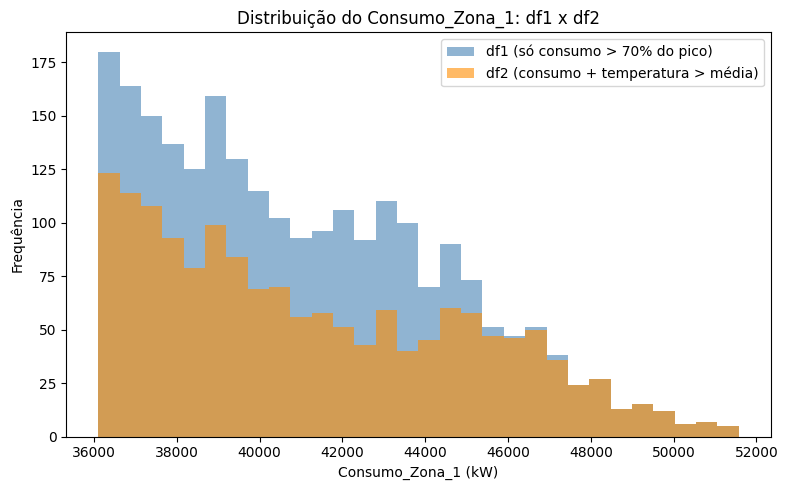

In [242]:
plt.figure(figsize=(8,5))
plt.hist(df1['Consumo_Zona_1'], bins=30, alpha=0.6, label='df1 (só consumo > 70% do pico)', color='steelblue')
plt.hist(df2['Consumo_Zona_1'], bins=30, alpha=0.6, label='df2 (consumo + temperatura > média)', color='darkorange')
plt.title('Distribuição do Consumo_Zona_1: df1 x df2')
plt.xlabel('Consumo_Zona_1 (kW)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

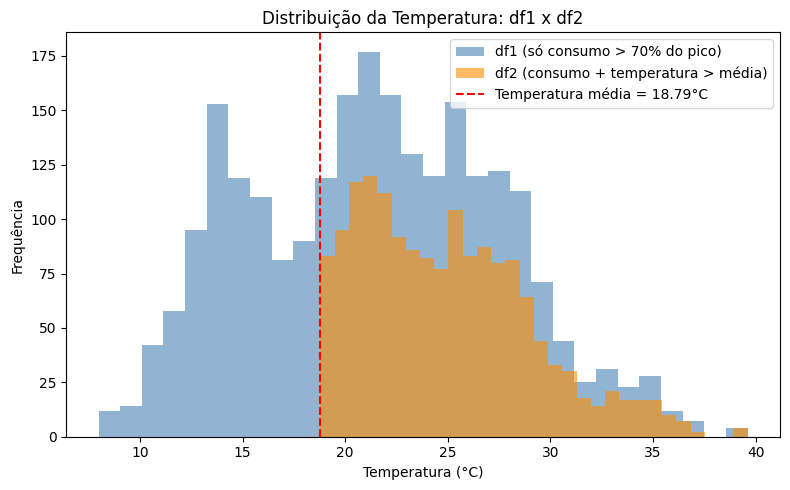

In [243]:
#HISTOGRAMA COMPARATIVO DA TEMPERATURA (df1 x df2)
plt.figure(figsize=(8,5))
plt.hist(df1['Temperature'], bins=30, alpha=0.6, label='df1 (só consumo > 70% do pico)', color='steelblue')
plt.hist(df2['Temperature'], bins=30, alpha=0.6, label='df2 (consumo + temperatura > média)', color='darkorange')
plt.axvline(meantemp, color='red', linestyle='--', label=f'Temperatura média = {meantemp:.2f}°C')
plt.title('Distribuição da Temperatura: df1 x df2')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

In [244]:
'''
O gráfico de temperatura evidencia bem o efeito do filtro: em df1 a
temperatura varia livremente (inclusive abaixo da média, já que não
havia restrição), enquanto em df2 toda a massa de dados fica à direita
da linha da temperatura média — exatamente o que se espera de um filtro
Temperature > meantemp. Já no histograma do consumo, as duas distribuições
continuam ocupando a mesma faixa de valores (ambas acima do limiar de 70%),
mas df2 tem menos observações concentradas, confirmando numericamente que a
condição ambiental reduziu o conjunto de registros sem alterar a faixa de
consumo analisada. Ou seja: a condição de temperatura filtra quando os
picos de alta demanda acontecem, não o quanto eles consomem.
'''

'\nO gráfico de temperatura evidencia bem o efeito do filtro: em df1 a\ntemperatura varia livremente (inclusive abaixo da média, já que não\nhavia restrição), enquanto em df2 toda a massa de dados fica à direita\nda linha da temperatura média — exatamente o que se espera de um filtro\nTemperature > meantemp. Já no histograma do consumo, as duas distribuições\ncontinuam ocupando a mesma faixa de valores (ambas acima do limiar de 70%),\nmas df2 tem menos observações concentradas, confirmando numericamente que a\ncondição ambiental reduziu o conjunto de registros sem alterar a faixa de\nconsumo analisada. Ou seja: a condição de temperatura filtra quando os\npicos de alta demanda acontecem, não o quanto eles consomem.\n'

##Dataset 4: Solar Power Generation Data - Kaggle

**Fonte:** https://www.kaggle.com/datasets/anikannal/solar-power-generation-data

**Situação:**
Uma equipe de operação de uma usina fotovoltaica deseja localizar períodos de alta geração e identificar quais inversores aparecem com maior frequência nesses momentos. Nesta atividade, o foco inicial será o arquivo de geração da planta, sem realizar junção com o arquivo de sensores.

**Colunas:**
DATE_TIME, SOURCE_KEY, DC_POWER, AC_POWER, DAILY_YIELD e TOTAL_YIELD

**Tamanho da Amostra:**
20% dos registros

####Fluxo do Orange:
IMAGEM_GENERATION.svg

####Etapas:

1. Carregue a amostra e renomeie as principais variáveis para nomes mais claros, como Potencia_CC, Potencia_CA e Geracao_Diaria.

2. Apresente head(), shape, info() e describe().

3. Determine a maior potência CA registrada.

4. Calcule um limiar correspondente a 70% da potência CA máxima.

5. Crie um DataFrame contendo somente registros acima desse limite e calcule sua quantidade e percentual.

6. Utilize value_counts() em SOURCE_KEY dentro do DataFrame de alta geração.

7. Identifique qual inversor aparece com maior frequência nos registros de alta geração e descreva o que esse resultado permite observar, sem concluir desempenho ou falha apenas com esse recorte.

In [245]:
df1 = pd.read_csv('/content/solar_power_generation_data_sample.csv')

In [246]:
df1.head()

,DATE_TIME,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,10-06-2020 19:00,uHbuxQJl8lW7ozc,0.00,0.000,6645.000,7240508.000
1,28-05-2020 00:15,rGa61gmuvPhdLxV,0.00,0.000,0.000,7206549.000
2,17-05-2020 15:15,sjndEbLyjtCKgGv,7333.88,718.062,6442.000,7036055.000
3,01-06-2020 04:15,ih0vzX44oOqAx2f,0.00,0.000,0.000,6308232.000
4,17-05-2020 09:00,z9Y9gH1T5YWrNuG,7665.50,750.438,961.375,7021701.375


In [247]:
print((f'Número de linhas: {df1.shape[0]}'))
print((f'Número de colunas: {df1.shape[1]}'))

Número de linhas: 13756
Número de colunas: 6


In [248]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13756 entries, 0 to 13755
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    13756 non-null  object 
 1   SOURCE_KEY   13756 non-null  object 
 2   DC_POWER     13756 non-null  float64
 3   AC_POWER     13756 non-null  float64
 4   DAILY_YIELD  13756 non-null  float64
 5   TOTAL_YIELD  13756 non-null  float64
dtypes: float64(4), object(2)
memory usage: 644.9+ KB


In [249]:
df1.describe()

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,13756.000000,13756.000000,13756.000000,1.375600e+04
mean,3135.848662,306.695495,3319.235216,6.978829e+06
std,4023.069619,393.124284,3142.249927,4.162164e+05
min,0.000000,0.000000,0.000000,6.183645e+06
25%,0.000000,0.000000,0.000000,6.509779e+06
50%,370.071500,35.771400,2730.425000,7.146218e+06
75%,6350.562500,622.065500,6293.782500,7.267996e+06
max,14416.100000,1405.590000,9163.000000,7.846821e+06


In [250]:
# Renomeando as colunas conforme pedido na atividade
df1 = df1.rename(columns={
    'DC_POWER': 'Potencia_CC',
    'AC_POWER': 'Potencia_CA',
    'DAILY_YIELD': 'Geracao_Diaria',
    'TOTAL_YIELD': 'Geracao_Total'
})

In [251]:
# Maior potência CA registrada (olhando seu describe, o max é ~1405.59)
max_ac = df1['Potencia_CA'].max()
print(f"Maior Potência CA: {max_ac:.2f}")

# Limiar de 70%
limiar_70 = max_ac * 0.70
print(f"Limiar de 70%: {limiar_70:.2f}")

Maior Potência CA: 1405.59
Limiar de 70%: 983.91


In [252]:
# Filtrando o DataFrame
df_alta_geracao = df1[df1['Potencia_CA'] > limiar_70]

qtd_alta = len(df_alta_geracao)
total_registros = len(df1)
percentual = (qtd_alta / total_registros) * 100

print(f"Quantidade de registros acima do limiar: {qtd_alta}")
print(f"Percentual em relação ao total: {percentual:.2f}%")

Quantidade de registros acima do limiar: 1185
Percentual em relação ao total: 8.61%


In [253]:
# Frequência de cada inversor (SOURCE_KEY) no recorte de alta geração
frequencia_inversores = df_alta_geracao['SOURCE_KEY'].value_counts()
print(frequencia_inversores)

SOURCE_KEY
adLQvlD726eNBSB    68
McdE0feGgRqW7Ca    65
ZnxXDlPa8U1GXgE    63
pkci93gMrogZuBj    62
ZoEaEvLYb1n2sOq    61
1IF53ai7Xc0U56Y    59
YxYtjZvoooNbGkE    58
sjndEbLyjtCKgGv    57
z9Y9gH1T5YWrNuG    56
uHbuxQJl8lW7ozc    55
zVJPv84UY57bAof    54
zBIq5rxdHJRwDNY    53
ih0vzX44oOqAx2f    53
WRmjgnKYAwPKWDb    52
3PZuoBAID5Wc2HD    51
iCRJl6heRkivqQ3    51
VHMLBKoKgIrUVDU    51
wCURE6d3bPkepu2    49
rGa61gmuvPhdLxV    43
7JYdWkrLSPkdwr4    43
1BY6WEcLGh8j5v7    42
bvBOhCH3iADSZry    39
Name: count, dtype: int64


In [254]:
#Identifique qual inversor aparece com maior frequência nos registros de alta geração e descreva o que esse resultado permite observar, sem concluir desempenho ou falha apenas com esse recorte.

'''
O inversor foi o que apareceu com maior frequência nos registros de alta
geração, com 68 ocorrências.

Isso mostra que, considerando o limite de 70% da potência CA máxima,
esse inversor esteve presente mais vezes nos momentos em que a geração
estava mais alta dentro da amostra analisada.

Porém, apenas esse resultado não é suficiente para dizer que esse inversor
tem um desempenho melhor que os outros ou que os demais apresentam algum
problema. Para chegar a esse tipo de conclusão, seria necessário analisar
outros dados e indicadores, além de considerar um período maior de informações.
'''

'\nO inversor foi o que apareceu com maior frequência nos registros de alta\ngeração, com 68 ocorrências.\n\nIsso mostra que, considerando o limite de 70% da potência CA máxima,\nesse inversor esteve presente mais vezes nos momentos em que a geração\nestava mais alta dentro da amostra analisada.\n\nPorém, apenas esse resultado não é suficiente para dizer que esse inversor\ntem um desempenho melhor que os outros ou que os demais apresentam algum\nproblema. Para chegar a esse tipo de conclusão, seria necessário analisar\noutros dados e indicadores, além de considerar um período maior de informações.\n'

##Dataset 5: Wind & Solar Energy Production Dataset - Kaggle

**Fonte:** https://www.kaggle.com/datasets/ahmeduzaki/wind-and-solar-energy-production-dataset

**Situação:**
Um operador de um portfólio de fontes renováveis deseja comparar a ocorrência de períodos de alta produção solar e alta produção eólica. Como as duas fontes possuem escalas próprias, cada uma deverá ser comparada com o seu próprio valor máximo.

**Colunas:**
atributos temporais e as variáveis de produção solar e eólica

**Tamanho da Amostra:**
20% dos registros

####Fluxo do Orange:
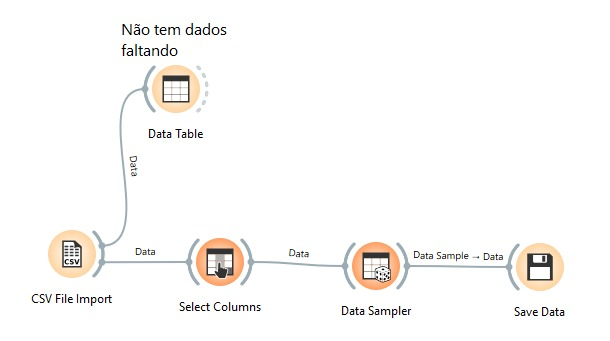

####Etapas:

1. Renomeie as variáveis principais para Geracao_Solar e Geracao_Eolica.

2. Determine o valor máximo registrado para cada fonte.

3. Calcule separadamente 70% do máximo solar e 70% do máximo eólico.

4. Crie um DataFrame para registros de alta geração solar e outro para registros de alta geração eólica.

5. Conte os registros de cada DataFrame e calcule seus respectivos percentuais.

6. Compare qual fonte aparece com maior frequência acima de 70% do seu próprio máximo.

7. Explique por que não seria adequado utilizar diretamente o mesmo valor numérico de potência como limite para as duas fontes sem antes observar a escala de cada variável.

In [255]:
ds5 = pd.read_csv('/content/wind_solar_energy_production_dataset_sample.csv')

In [256]:
#Informações sobre o formato dos dados
ds5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10375 entries, 0 to 10374
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         10374 non-null  object
 1   Start_Hour   10374 non-null  object
 2   End_Hour     10374 non-null  object
 3   Source       10374 non-null  object
 4   Day_of_Year  10374 non-null  object
 5   Day_Name     10374 non-null  object
 6   Month_Name   10374 non-null  object
 7   Season       10374 non-null  object
 8   Production   10374 non-null  object
dtypes: object(9)
memory usage: 729.6+ KB


In [257]:
#Rótulos das colunas (nome dos atributos)
ds5.columns

Index(['Date', 'Start_Hour', 'End_Hour', 'Source', 'Day_of_Year', 'Day_Name',
       'Month_Name', 'Season', 'Production'],
      dtype='object')

In [258]:
#Renomear os rótulos:
ds5 = ds5.rename({'Date': 'Data',
                      'Start_Hour': 'Hora_Inicial',
                      'End_Hour': 'Hora_Final',
                      'Source': 'Fonte',
                      'Day_of_Year': 'Dia_do_Ano',
                      'Day_Name': 'Dia_Semana',
                      'Month_Name': 'Mês',
                      'Production': 'Produção',
                      'Season': 'Estação'}, axis = 1)

In [259]:
#Determinar o valor máximo para cada fonte e calcule 70% do máximo de cada fonte de energia

#Remover as linhas sem Fonte ou Produção
ds5 = ds5.dropna(subset=['Fonte', 'Produção'])

#Garintir que a Produção seja numérica
ds5['Produção'] = pd.to_numeric(ds5['Produção'], errors='coerce')

#Encontrando o máximo de produção de cada fonte
resultado5 = ds5.groupby('Fonte')['Produção'].max().reset_index()

#Renomear
resultado5 = resultado5.rename(columns={
    'Produção': 'Produção Máxima'
})

#Calcular 70%
resultado5['70% do Máximo'] = resultado5['Produção Máxima'] * 0.70

print(resultado5)

              Fonte  Produção Máxima  70% do Máximo
0  Mixed Solar Wind              NaN            NaN
1             Solar          16316.0        11421.2
2              Wind          22929.0        16050.3


In [260]:
#Dataframe para registros de alta geração solar e eólica, calcular seus percentuais
# Máximo de cada fonte
maximos = ds5.groupby('Fonte')['Produção'].transform('max')

# 70% do máximo de cada fonte
limite_70 = maximos * 0.70

# DataFrame de alta geração solar
alta_solar = ds5[
    (ds5['Fonte'] == 'Solar') &
    (ds5['Produção'] >= limite_70)
]

# DataFrame de alta geração eólica
alta_eolica = ds5[
    (ds5['Fonte'] == 'Wind') &
    (ds5['Produção'] >= limite_70)
]

# Quantidade de registros
qtd_solar = len(alta_solar)
qtd_eolica = len(alta_eolica)

# Total de registros válidos
total = len(ds5)

# Percentuais
percentual_solar = (qtd_solar / total) * 100
percentual_eolica = (qtd_eolica / total) * 100

print("Alta geração solar:", qtd_solar)
print("Percentual solar:", percentual_solar, "%")

print("Alta geração eólica:", qtd_eolica)
print("Percentual eólica:", percentual_eolica, "%")

Alta geração solar: 45
Percentual solar: 0.43377674956622325 %
Alta geração eólica: 245
Percentual eólica: 2.3616734143049936 %


In [261]:
#Coparando qual a fonte aparece mais vezes, explicando por que nao é adequado utilizar o mesmo valor de potência como limite para as fontes sem observar a escala das variáveis

print("Solar:", len(alta_solar))
print("Eólica:", len(alta_eolica))

Solar: 45
Eólica: 245


In [262]:
'''
Não é adequado utilizar o mesmo valor numérico de potência como limite para
as duas fontes porque Solar e Wind possuem escalas de geração diferentes.
Um valor que representa uma geração alta para uma fonte pode representar
uma geração baixa para outra. Por isso, o limite de 70% é calculado com
base no máximo de cada fonte individualmente, tornando a comparação
proporcional e mais justa.
'''

'\nNão é adequado utilizar o mesmo valor numérico de potência como limite para\nas duas fontes porque Solar e Wind possuem escalas de geração diferentes.\nUm valor que representa uma geração alta para uma fonte pode representar\numa geração baixa para outra. Por isso, o limite de 70% é calculado com\nbase no máximo de cada fonte individualmente, tornando a comparação\nproporcional e mais justa.\n'

##Dataset 6: Individual Household Electric Power Consumption - UCI

**Fonte:** https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

**Situação:**
Uma residência possui monitoramento elétrico detalhado e deseja identificar episódios de demanda elevada que também apresentem corrente acima do comportamento médio. O dataset é o mesmo utilizado como referência em aula, mas o critério de análise será diferente.

**Colunas:**
Global_active_power, Global_reactive_power, Voltage, Global_intensity e os três atributos Sub_metering

**Tamanho da Amostra:**
10% dos registros

####Fluxo do Orange:
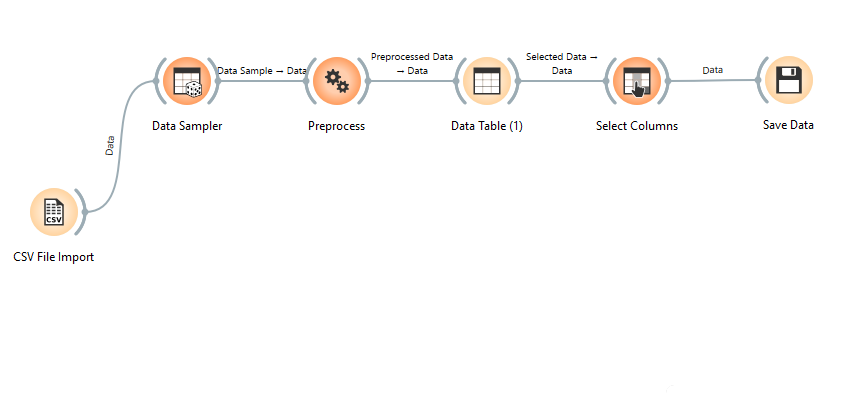

####Etapas:

1. Carregue a nova amostra e organize os atributos utilizando nomes mais simples.

2. Determine o valor máximo de potência ativa.

3. Calcule 75% do valor máximo e crie um DataFrame contendo registros acima desse limite.

4. Calcule a quantidade e o percentual de registros selecionados.

5. Calcule a corrente média da amostra.

6. Crie um segundo DataFrame contendo simultaneamente potência ativa acima de 75% do máximo e corrente acima da média.

7. Compare os dois conjuntos e explique o efeito da inclusão da corrente como segunda condição.

In [263]:
# 1. Carregar a amostra e renomear os atributos para nomes mais simples
df = pd.read_csv('/content/individual_household_eletric_power_consumption_sample.csv')

df = df.rename(columns={
    'Global_active_power': 'potencia_ativa',
    'Global_reactive_power': 'potencia_reativa',
    'Voltage': 'tensao',
    'Global_intensity': 'corrente',
    'Sub_metering_1': 'sub_1',
    'Sub_metering_2': 'sub_2',
    'Sub_metering_3': 'sub_3'
})

print(f'Tamanho da amostra: {df.shape[0]} registros e {df.shape[1]} atributos')
df.head()

Tamanho da amostra: 204923 registros e 7 atributos


,potencia_ativa,potencia_reativa,tensao,corrente,sub_1,sub_2,sub_3
0,0.256,0.106,242.00,1.2,0,0,1
1,0.466,0.352,237.22,2.4,0,2,0
2,0.758,0.194,238.66,3.2,0,1,0
3,1.290,0.046,240.64,5.4,1,0,18
4,0.428,0.202,242.23,1.8,0,2,1


In [264]:
# 2. Determinar o valor máximo de potência ativa
p_max = df['potencia_ativa'].max()

# 3. Calcular 75% do valor máximo e criar DataFrame com registros acima desse limite
limite_75 = 0.75 * p_max
df1 = df[df['potencia_ativa'] > limite_75]

# 4. Calcular a quantidade e o percentual de registros selecionados
qtd_df1 = len(df1)
pct_df1 = (qtd_df1 / len(df)) * 100

print(f'Potência Ativa Máxima: {p_max:.2f} kW')
print(f'Limite de 75% do Máximo: {limite_75:.4f} kW')
print(f'Quantidade de registros acima do limite (df1): {qtd_df1}')
print(f'Percentual na amostra: {pct_df1:.4f}%')

df1.head()

Potência Ativa Máxima: 10.65 kW
Limite de 75% do Máximo: 7.9875 kW
Quantidade de registros acima do limite (df1): 33
Percentual na amostra: 0.0161%


,potencia_ativa,potencia_reativa,tensao,corrente,sub_1,sub_2,sub_3
24316,8.110,0.196,236.87,34.2,37,74,17
42227,8.026,0.058,234.91,34.0,37,73,17
45375,8.218,0.336,236.05,34.8,37,73,17
46232,9.708,0.372,231.37,42.0,37,69,17
54976,8.168,0.540,228.91,35.6,35,35,17


In [265]:
# 5. Calcular a corrente média da amostra
corrente_media = df['corrente'].mean()

# 6. Criar segundo DataFrame com potência ativa > 75% do máximo E corrente > média
df2 = df[(df['potencia_ativa'] > limite_75) & (df['corrente'] > corrente_media)]

# Cálculo da quantidade, percentual e menor corrente de df2
qtd_df2 = len(df2)
pct_df2 = (qtd_df2 / len(df)) * 100
menor_corrente_df1 = df1['corrente'].min()

print(f'Corrente Média da Amostra: {corrente_media:.4f} A')
print(f'Quantidade de registros na dupla condição (df2): {qtd_df2}')
print(f'Percentual na amostra: {pct_df2:.4f}%')
print(f'Menor corrente entre os registros de df1: {menor_corrente_df1:.2f} A')

df2.head()

Corrente Média da Amostra: 4.6376 A
Quantidade de registros na dupla condição (df2): 33
Percentual na amostra: 0.0161%
Menor corrente entre os registros de df1: 33.80 A


,potencia_ativa,potencia_reativa,tensao,corrente,sub_1,sub_2,sub_3
24316,8.110,0.196,236.87,34.2,37,74,17
42227,8.026,0.058,234.91,34.0,37,73,17
45375,8.218,0.336,236.05,34.8,37,73,17
46232,9.708,0.372,231.37,42.0,37,69,17
54976,8.168,0.540,228.91,35.6,35,35,17


In [266]:
#Resultado obtido
'''
O primeiro conjunto de dados (df1) obteve 33 registros, correspondendo a
aproximadamente 0,0161% da amostra. Ao aplicar a segunda condição, de
corrente elétrica acima da média da amostra, o conjunto (df2) manteve
os mesmos 33 registros.
'''

#Interpretação
'''
Os resultados mostram que todos os registros que apresentaram
potência ativa superior a 75% do valor máximo também apresentaram
corrente acima da média da amostra. Como a potência elétrica está
relacionada à tensão, à corrente e ao fator de potência, é esperado que
valores elevados de potência possam estar associados a correntes elevadas.
Neste caso, porém, a conclusão deve ser limitada aos dados analisados: a
segunda condição não excluiu nenhum dos registros selecionados por potência.
'''

#Conclusão
'''
A inclusão da corrente acima da média como segunda condição não
alterou o conjunto de resultados. Portanto, para esta amostra, a
condição de corrente não acrescentou uma nova restrição aos episódios de
potência ativa elevada, pois os 33 registros selecionados inicialmente
já estavam acima da corrente média.
'''

'\nA inclusão da corrente acima da média como segunda condição não\nalterou o conjunto de resultados. Portanto, para esta amostra, a\ncondição de corrente não acrescentou uma nova restrição aos episódios de\npotência ativa elevada, pois os 33 registros selecionados inicialmente\njá estavam acima da corrente média.\n'